In [1]:
# Import required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Dataset 
df=pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [46]:
# Descriptive Statistics for numerical columns

df[['time_in_hospital','num_lab_procedures','num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


# Distribution of Race and Gender

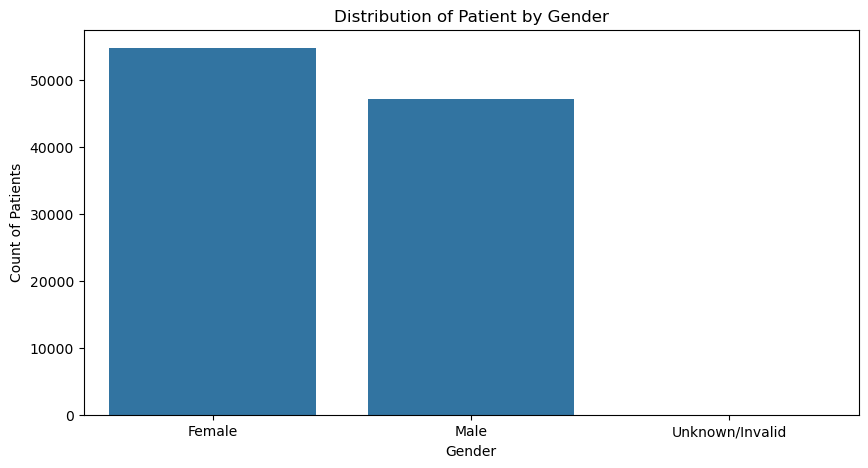

In [54]:
# Distribution of Gender

plt.figure(figsize=(10,5))
sns.countplot(x='gender', data=df)
plt.title("Distribution of Patient by Gender")
plt.xlabel("Gender")
plt.ylabel("Count of Patients")
plt.show()

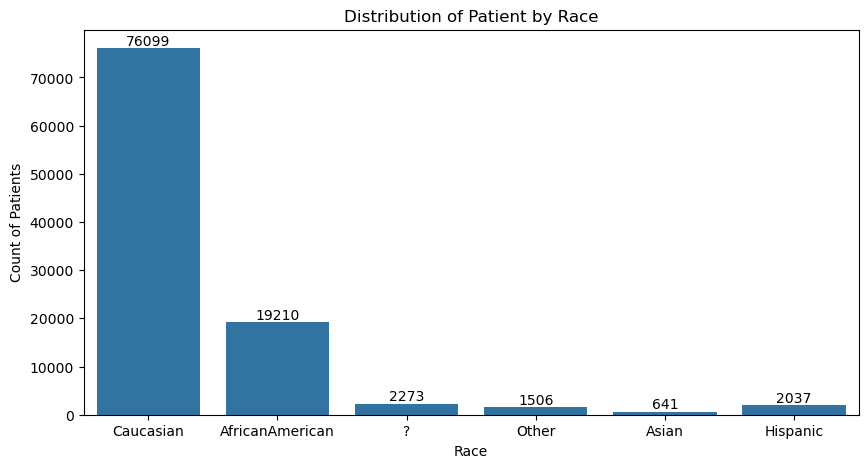

In [55]:
# Distribution of Race
plt.figure(figsize=(10,5))
ax=sns.countplot(x='race', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title ("Distribution of Patient by Race")
plt.xlabel("Race")
plt.ylabel("Count of Patients")
plt.show()

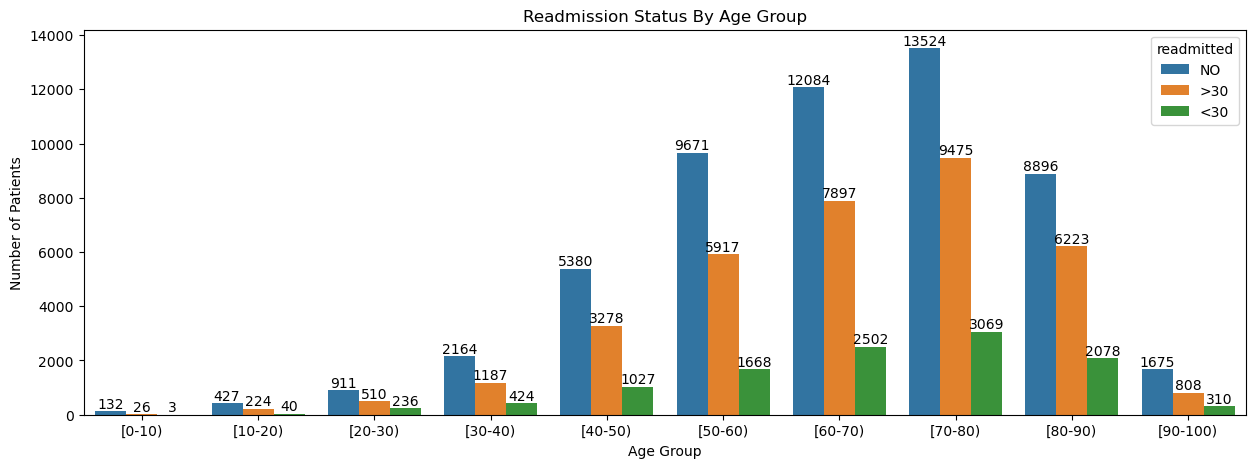

In [15]:
# Relation between Readmission and Age

plt.figure(figsize=(15,5))
ax=sns.countplot(x='age', hue='readmitted', data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Readmission Status By Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()

# Correlation Analysis

In [47]:
# Correlation Analysis

num_columns=['time_in_hospital','num_lab_procedures','num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

In [48]:
corr_matrix= df[num_columns].corr()
corr_matrix

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.000000,0.318450,0.191472,0.466135,-0.008916,-0.009681,0.073623,0.220186
num_lab_procedures,0.318450,1.000000,0.058066,0.268161,-0.007602,-0.002279,0.039231,0.152773
num_procedures,0.191472,0.058066,1.000000,0.385767,-0.024819,-0.038179,-0.066236,0.073734
num_medications,0.466135,0.268161,0.385767,1.000000,0.045197,0.013180,0.064194,0.261526
number_outpatient,-0.008916,-0.007602,-0.024819,0.045197,1.000000,0.091459,0.107338,0.094152
number_emergency,-0.009681,-0.002279,-0.038179,0.013180,0.091459,1.000000,0.266559,0.055539
number_inpatient,0.073623,0.039231,-0.066236,0.064194,0.107338,0.266559,1.000000,0.104710
number_diagnoses,0.220186,0.152773,0.073734,0.261526,0.094152,0.055539,0.104710,1.000000


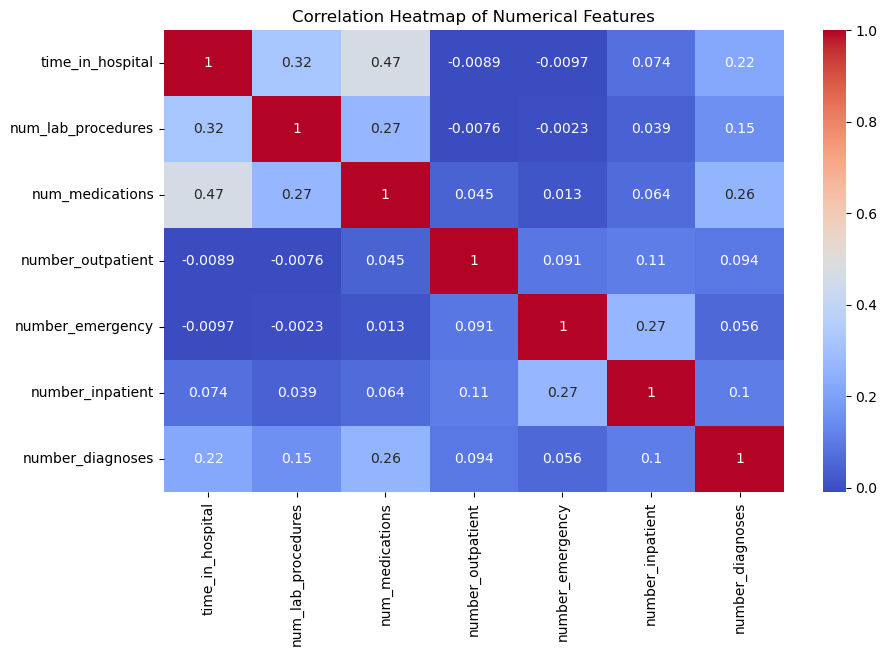

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

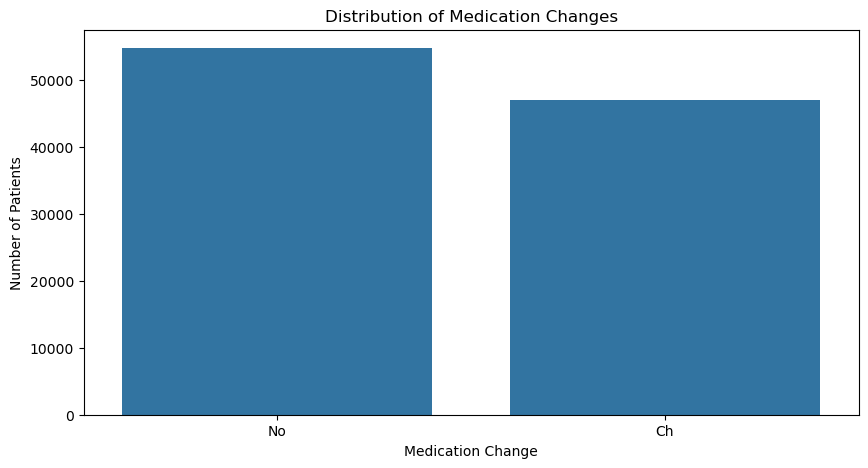

In [23]:
# Distribution of Medication Change
plt.figure(figsize=(10,5))
sns.countplot(x='change', data=df)
plt.title("Distribution of Medication Changes")
plt.xlabel("Medication Change")
plt.ylabel("Number of Patients")
plt.show()

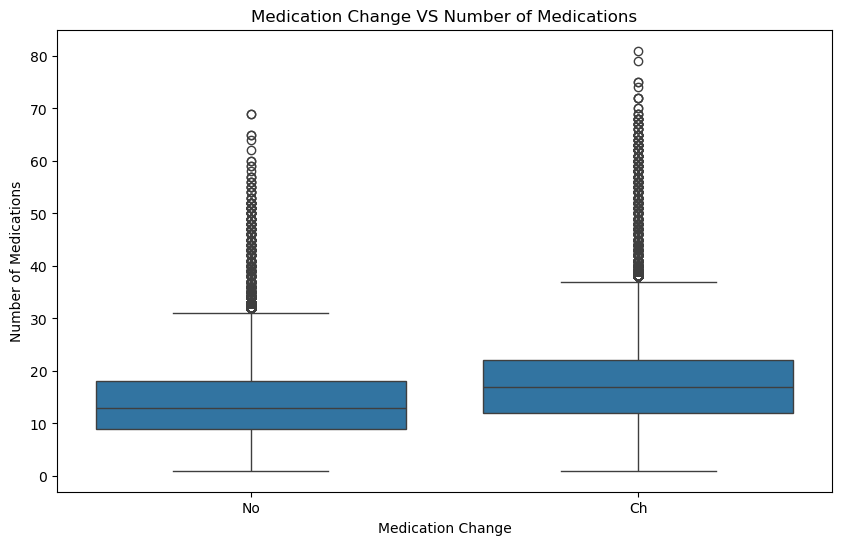

In [28]:
# Relationship between Medication Change and Number of Medications

plt.figure(figsize=(10,6))
sns.boxplot(x='change', y='num_medications', data=df)
plt.title("Medication Change VS Number of Medications")
plt.xlabel("Medication Change")
plt.ylabel("Number of Medications")
plt.show()

# Distribution of Diagnosis Categories

In [31]:
# Combine diagnosis columns

diagnosis_data= pd.concat([df['diag_1'], df['diag_2'], df['diag_3']])
diagnosis_data= diagnosis_data[diagnosis_data != '?']

In [32]:
diagnosis_data

0         250.83
1            276
2            648
3              8
4            197
           ...  
101761       458
101762       787
101763       296
101764       998
101765       787
Length: 303496, dtype: object

In [33]:
# Find Top 10 Diagnosis

top_diagnosis= diagnosis_data.value_counts().head(10)
top_diagnosis

428    18101
250    17861
276    13816
414    12895
401    12371
427    11757
599     6824
496     5990
403     5693
486     5455
Name: count, dtype: int64

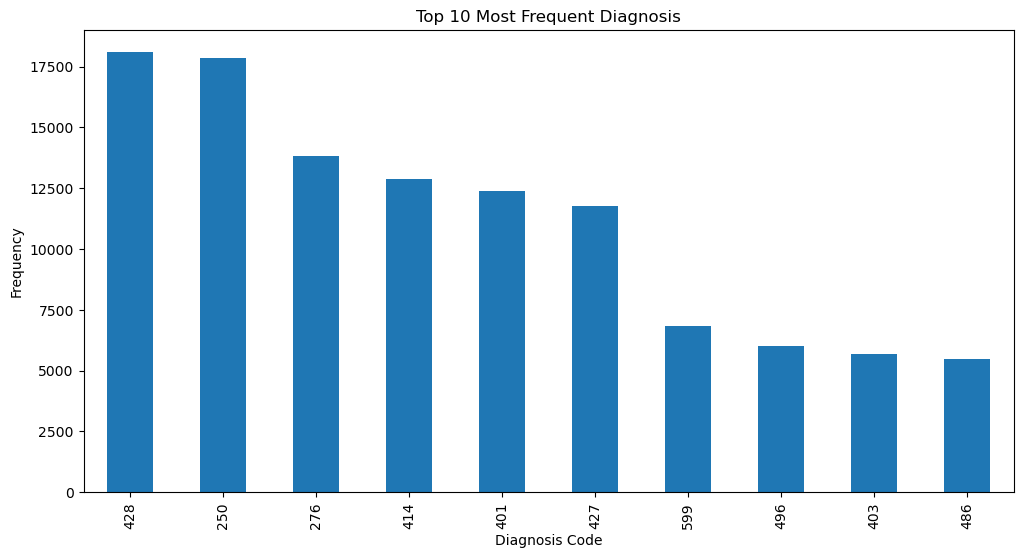

In [37]:
# Visualize Top Diagnosis

plt.figure(figsize=(12,6))
top_diagnosis.plot(kind='bar')
plt.title("Top 10 Most Frequent Diagnosis")
plt.xlabel("Diagnosis Code")
plt.ylabel("Frequency")
plt.show()

# Distribution of Admission types, Admission Sourcces, Discharge Dispositions

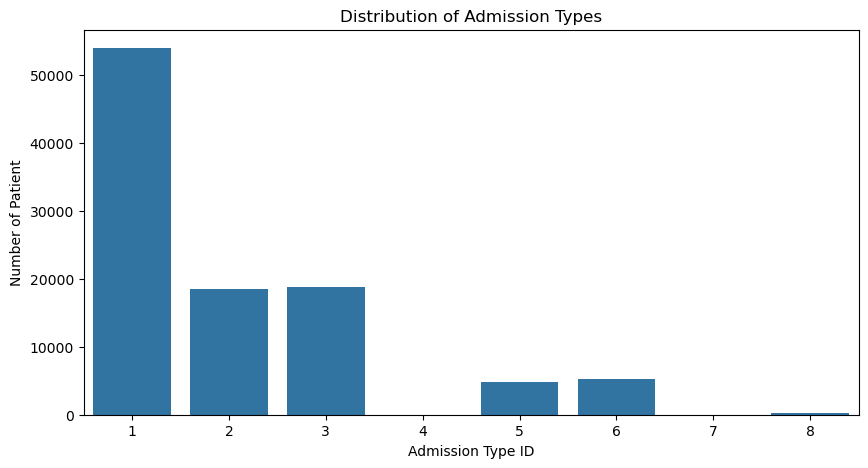

In [42]:
# Distribution of admission types

plt.figure(figsize=(10,5))
sns.countplot(x='admission_type_id', data=df)
plt.title("Distribution of Admission Types")
plt.xlabel("Admission Type ID")
plt.ylabel("Number of Patient")
plt.show()

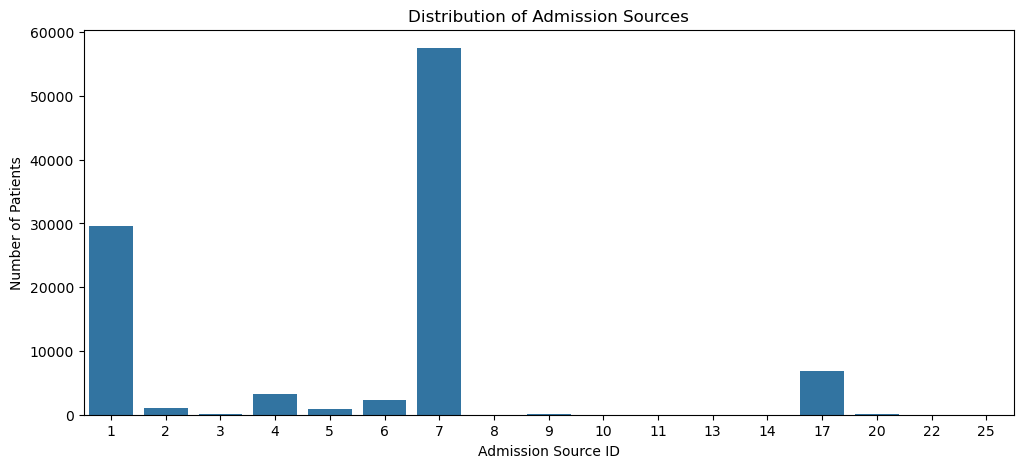

In [44]:
# Distribution of Admission Sources

plt.figure(figsize=(12,5))
sns.countplot(x='admission_source_id', data=df)
plt.title("Distribution of Admission Sources")
plt.xlabel("Admission Source ID")
plt.ylabel("Number of Patients")
plt.show()

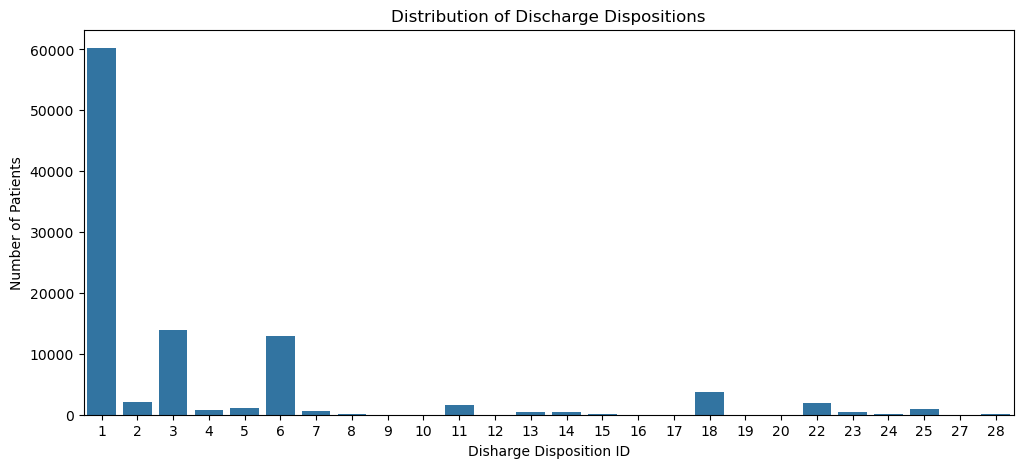

In [45]:
# Distribution of Discharge Disposition

plt.figure(figsize=(12,5))
sns.countplot(x='discharge_disposition_id', data=df)
plt.title("Distribution of Discharge Dispositions")
plt.xlabel("Disharge Disposition ID")
plt.ylabel("Number of Patients")
plt.show()

# Outlier Detection in Numerical columns

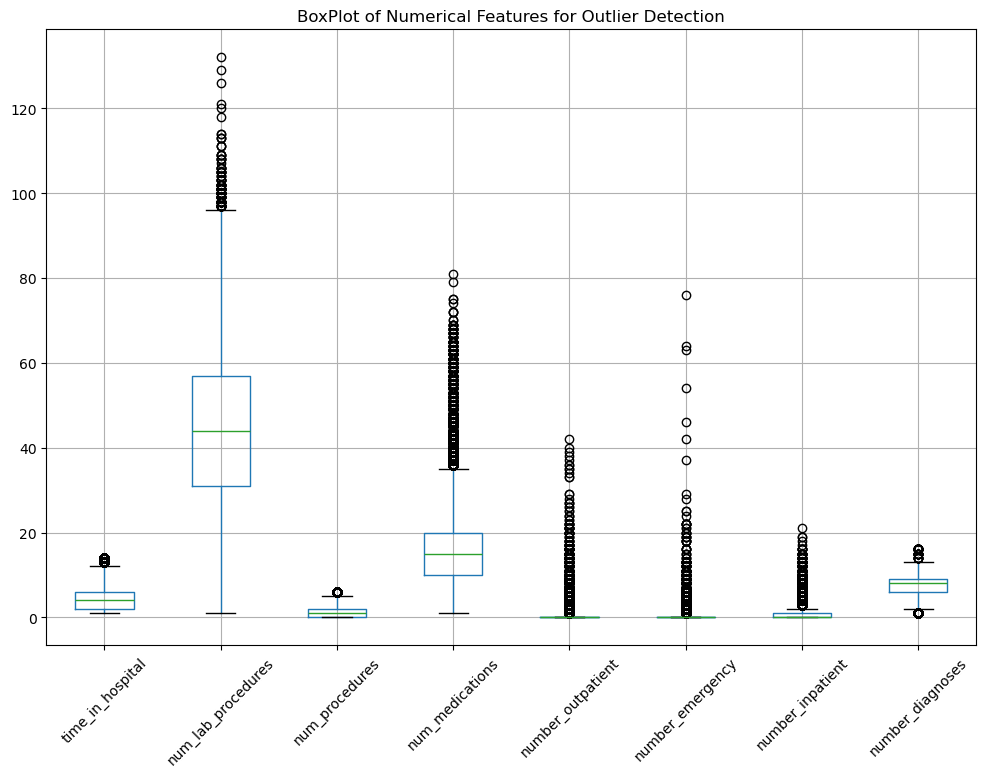

In [52]:
plt.figure(figsize=(12,8))
df[num_columns].boxplot()
plt.title("BoxPlot of Numerical Features for Outlier Detection")
plt.xticks(rotation=45)
plt.show()
